# Zero-shot оценка pretrained Simple-BEV на наших данных

Цель: понять какой IoU даёт их nuScenes-pretrained модель на нашем датасете без какого-либо обучения.

**Реалистичный прогноз**: 0.05-0.20 IoU (плохо). Причины:
1. Их класс — vehicle (машины), наш — static obstacle (стены/отбойники)
2. Их BEV покрывает ±50м forward, наша — 0..150м forward → 67% нашей области их модель не видит
3. Их rig — 6 камер по кругу, у нас 4 камеры все смотрят вперёд

Если получится хотя бы 0.10 — есть смысл finetune. Если 0 — лучше пойти Plan C (только backbone weights в нашу модель).

**Запускать ТОЛЬКО на cuda** — Simple-BEV хардкодит `.cuda()` в нескольких местах, мы патчим часть из них.

In [1]:
!pip install efficientnet_pytorch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import time
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

from bev_v1 import BEVDataset, iou_binary_batch, BEV_H, BEV_W
from simplebev_adapter import SimpleBEVAdapter

if not torch.cuda.is_available():
    print("⚠️  Simple-BEV ОЧЕНЬ хочет cuda. На CPU/MPS могут быть проблемы.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}")

DATA_VAL = Path("./autonomy_yandex_dataset_val/")

device = cuda


## 1. Загружаем модель

In [3]:
adapter = SimpleBEVAdapter(device=device)
n_params = sum(p.numel() for p in adapter.model.parameters())
print(f"Simple-BEV total params: {n_params/1e6:.1f}M")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /tmp/xdg_cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:02<00:00, 61.0MB/s] 
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'w

[SimpleBEVAdapter] loaded external/simple_bev/checkpoints/8x5_5e-4_rgb12_22:43:46/model-000025000.pth
  missing: 2  unexpected: 0
  missing examples: ['mean', 'std']
Simple-BEV total params: 42.0M


## 2. Quick forward — проверка что вообще работает

Берём 1 батч, прогоняем, печатаем формы. Если падает — диагностируем по traceback.

In [4]:
# Им нужно изображение в формате близком к их обучению —
# (224, 480) или (448, 800). Возьмём 448x800 (как в их eval).
IMG_HW = (448, 800)

ds = BEVDataset(DATA_VAL, mode="val", img_hw=IMG_HW)
loader = DataLoader(ds, batch_size=2, shuffle=False, num_workers=0)

batch = next(iter(loader))
images = batch["images"].to(device)
intr = batch["intrinsics"].to(device)
c2c = batch["car2cams"].to(device)
gt = batch["gt"]

print(f"images: {tuple(images.shape)}")
print(f"intrinsics: {tuple(intr.shape)}")
print(f"car2cams: {tuple(c2c.shape)}")
print(f"gt: {tuple(gt.shape)}")

# 1. Сначала forward_raw — их грид 200x200
t0 = time.time()
seg_raw = adapter.forward_raw(images, intr, c2c)
print(f"\nseg_raw shape (their BEV): {tuple(seg_raw.shape)}")
print(f"  logits range: {seg_raw.min().item():.2f} .. {seg_raw.max().item():.2f}")
print(f"  positive prob frac: {(seg_raw.sigmoid() > 0.5).float().mean().item():.3f}")
print(f"  time: {time.time()-t0:.1f}s")

# 2. forward — ремап на нашу сетку
seg_ours = adapter(images, intr, c2c)
print(f"\nseg (our grid): {tuple(seg_ours.shape)}")
assert seg_ours.shape[-2:] == (BEV_H, BEV_W), f"unexpected shape {seg_ours.shape}"

images: (2, 4, 3, 448, 800)
intrinsics: (2, 4, 3, 3)
car2cams: (2, 4, 4, 4)
gt: (2, 1, 188, 126)

seg_raw shape (their BEV): (2, 1, 200, 200)
  logits range: -47.39 .. 8.22
  positive prob frac: 0.009
  time: 1.9s

seg (our grid): (2, 1, 188, 126)


## 3. Визуализация — самое важное

Смотрим: их 200×200 prediction слева, наша 188×126 GT справа, их же prediction ремапнутый на нашу сетку посередине. Это покажет:
- работает ли вообще их модель
- правильно ли мы делаем resample
- видит ли она в принципе препятствия (хоть какие-то)

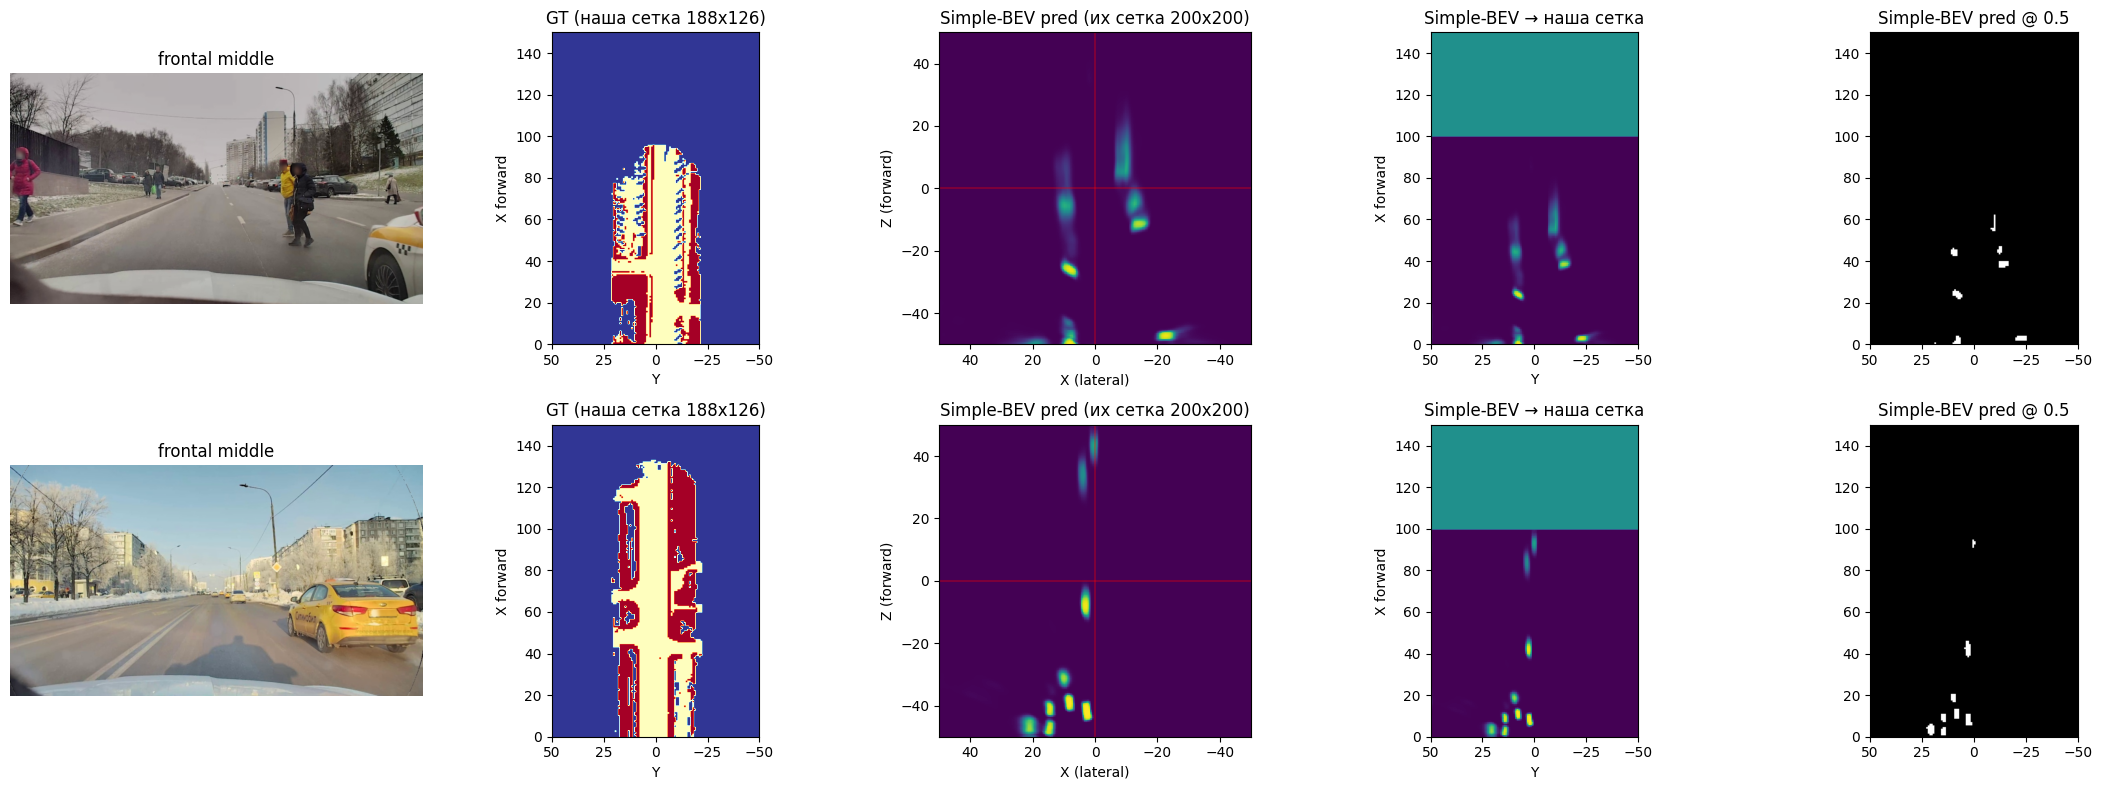

In [5]:
# Их BEV: (Z=forward[-50,50], X=lateral[-50,50])
# index [0, 0] = (z=-50, x=-50) — задняя левая угловая клетка
n = min(3, images.shape[0])
fig, axes = plt.subplots(n, 5, figsize=(22, 4*n))
if n == 1: axes = axes[None, :]

extent_simple = [-50, 50, -50, 50]   # их сетка (X lateral, Z forward)
extent_ours = [-50, 50, 0, 150]      # наша сетка

for k in range(n):
    # Cam middle (denorm для отображения)
    img_norm = images[k, 0].cpu().permute(1, 2, 0).numpy()
    img_show = np.clip(img_norm * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    axes[k, 0].imshow(img_show)
    axes[k, 0].set_title("frontal middle"); axes[k, 0].axis('off')

    # GT
    g = gt[k, 0].numpy().astype(np.float32)
    g[g == 255] = -1
    axes[k, 1].imshow(g, cmap="RdYlBu_r", extent=extent_ours, origin="lower", vmin=-1, vmax=1)
    axes[k, 1].invert_xaxis(); axes[k, 1].set_title("GT (наша сетка 188x126)"); axes[k, 1].set_xlabel('Y'); axes[k, 1].set_ylabel('X forward')

    # Их 200x200 raw prediction
    p_raw = seg_raw[k, 0].sigmoid().cpu().numpy()
    axes[k, 2].imshow(p_raw, cmap="viridis", extent=extent_simple, origin="lower", vmin=0, vmax=1)
    axes[k, 2].invert_xaxis()
    axes[k, 2].set_title("Simple-BEV pred (их сетка 200x200)")
    axes[k, 2].set_xlabel('X (lateral)'); axes[k, 2].set_ylabel('Z (forward)')
    axes[k, 2].axhline(0, color='red', alpha=0.3); axes[k, 2].axvline(0, color='red', alpha=0.3)

    # Их prediction ремапнутый на нашу сетку
    p_ours = seg_ours[k, 0].sigmoid().cpu().numpy()
    axes[k, 3].imshow(p_ours, cmap="viridis", extent=extent_ours, origin="lower", vmin=0, vmax=1)
    axes[k, 3].invert_xaxis(); axes[k, 3].set_title("Simple-BEV → наша сетка"); axes[k, 3].set_xlabel('Y'); axes[k, 3].set_ylabel('X forward')

    # Бинарный pred @ 0.5
    pb = (p_ours > 0.5).astype(np.float32)
    axes[k, 4].imshow(pb, cmap="gray", extent=extent_ours, origin="lower")
    axes[k, 4].invert_xaxis(); axes[k, 4].set_title("Simple-BEV pred @ 0.5")

plt.tight_layout(); plt.show()

**Что проверить глазами:**
1. На «Simple-BEV pred (их сетка)» — видны ли *хоть какие-то* активации в правдоподобных местах? Если ровный пустой синий — модель ничего не предсказывает.
2. На ремапнутой версии — соответствуют ли активные области нашему GT хотя бы в области X∈[0..50м]?
3. Если ремап выглядит зеркально — нужно поправить axis convention в `simplebev_adapter.py`.

## 4. IoU на val

Прогон на полном val (1000 семплов), батч 4, считаем IoU на разных threshold.

In [6]:
BATCH = 4
val_ds = BEVDataset(DATA_VAL, mode="val", img_hw=IMG_HW)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
intersections = {t: 0 for t in thresholds}
unions = {t: 0 for t in thresholds}

for batch in tqdm(val_loader, desc="zero-shot eval"):
    images = batch["images"].to(device)
    intr = batch["intrinsics"].to(device)
    c2c = batch["car2cams"].to(device)
    gt = batch["gt"].to(device)
    seg = adapter(images, intr, c2c)
    for t in thresholds:
        i, u = iou_binary_batch(seg.float(), gt, threshold=t)
        intersections[t] += i
        unions[t] += u

print("\n=== Zero-shot Simple-BEV IoU on val ===")
for t in thresholds:
    iou = intersections[t] / max(unions[t], 1)
    print(f"  threshold={t:.2f}  IoU = {iou:.4f}")

zero-shot eval: 100%|██████████| 250/250 [03:50<00:00,  1.08it/s]


=== Zero-shot Simple-BEV IoU on val ===
  threshold=0.30  IoU = 0.1521
  threshold=0.40  IoU = 0.1505
  threshold=0.50  IoU = 0.0102
  threshold=0.60  IoU = 0.0085
  threshold=0.70  IoU = 0.0069


## 5. Решение

По результату:
- **Если IoU < 0.05** — pretrained веса бесполезны как есть. Делаем Plan C (только image encoder weights в нашу `MultiCamBEV`).
- **Если 0.05 ≤ IoU < 0.20** — pretrained даёт что-то, имеет смысл finetune. Plan B (полный finetune Simple-BEV на нашем grid).
- **Если IoU ≥ 0.20** — неожиданно хорошо, finetune почти точно даст 0.55+.

Параллельно стоит проверить визуально: совпадают ли активные области их prediction с препятствиями на изображениях.